In [18]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


data = pd.read_csv('/content/SolarGlass Smartphone Dataset.csv')


In [7]:
# 2. PREPROCESSING
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

data['cleaned_text'] = data['Tweet_Text'].apply(clean_text)

In [8]:
# 3. SPLITTING DATA (80% Train, 20% Test)
X = data['cleaned_text']
y = data['Label']

# Fixed random_state ensures you get consistent results every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# 4. VECTORIZATION
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [10]:
# 5. MODEL TRAINING & EVALUATION

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)
print("--- Naive Bayes Report ---")
print(classification_report(y_test, nb_pred))

--- Naive Bayes Report ---
              precision    recall  f1-score   support

          -1       0.60      1.00      0.75         6
           0       0.83      0.83      0.83         6
           1       1.00      0.50      0.67         8

    accuracy                           0.75        20
   macro avg       0.81      0.78      0.75        20
weighted avg       0.83      0.75      0.74        20



In [11]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, lr_pred))


--- Logistic Regression Report ---
              precision    recall  f1-score   support

          -1       0.60      1.00      0.75         6
           0       0.80      0.67      0.73         6
           1       1.00      0.62      0.77         8

    accuracy                           0.75        20
   macro avg       0.80      0.76      0.75        20
weighted avg       0.82      0.75      0.75        20



In [12]:
# SVM
svm = SVC()
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)
print("--- SVM Report ---")
print(classification_report(y_test, svm_pred))


--- SVM Report ---
              precision    recall  f1-score   support

          -1       0.62      0.83      0.71         6
           0       0.83      0.83      0.83         6
           1       0.83      0.62      0.71         8

    accuracy                           0.75        20
   macro avg       0.76      0.76      0.75        20
weighted avg       0.77      0.75      0.75        20



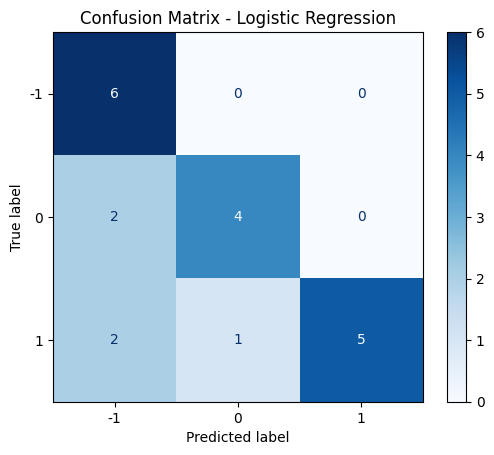

In [13]:
# 6. GRAPHS AND VISUALIZATIONS

# Confusion Matrix for the best model (Logistic Regression)
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [14]:
# Model Accuracy Comparison Graph
models = ['Naive Bayes', 'Logistic Regression', 'SVM']

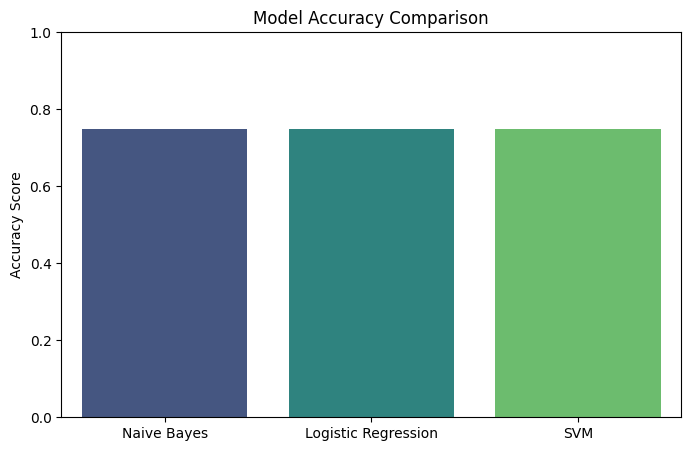

In [19]:
# Calculating actual accuracy from the predictions
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy Score")
plt.show()

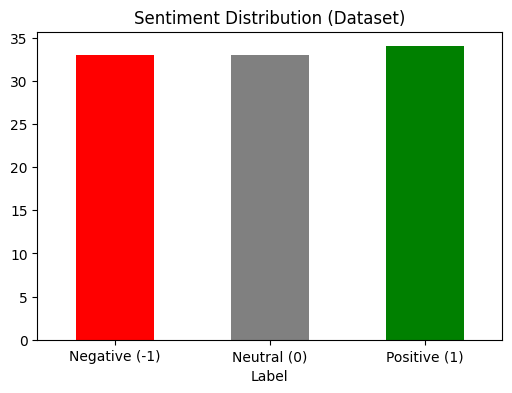

In [20]:
# Sentiment Distribution
plt.figure(figsize=(6, 4))
data['Label'].value_counts().sort_index().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title("Sentiment Distribution (Dataset)")
plt.xticks(ticks=[0, 1, 2], labels=['Negative (-1)', 'Neutral (0)', 'Positive (1)'], rotation=0)
plt.show()